#### Prédiction de la consommation totale d’énergie

In [1]:
# librairy

import polars as pl
import numpy as np
import pandas as pd
import statsmodels.api as sm
import shap

from sklearn.ensemble import GradientBoostingRegressor, BaggingRegressor,RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.svm import SVR

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# chargement des données clean
df = pl.read_csv("data_batiment_2016_clean.csv")
df.head()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,SiteEUI(kBtu/sf),SiteEnergyUse(kBtu),GHGEmissionsIntensity,ENERGYSTARScore,Electricity_Proportion(kBtu),SteamUse_Proportion(kBtu)
i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1,1927,1.0,12.0,88434.0,81.699997,7226362.5,2.83,60.0,0.54606,0.277302
1,2,1996,1.0,11.0,103566.0,94.800003,8.387933e6,2.86,61.0,0.297569,0.23031
2,3,1969,1.0,2.0,47237.0,96.0,2.6152e6,2.19,43.0,0.405656,0.223646
3,5,1926,1.0,10.0,61320.0,110.800003,6.794584e6,4.67,56.0,0.407519,0.325913
4,8,1980,1.0,18.0,175580.0,114.800003,1.4172606e7,2.88,75.0,0.290734,0.23249


In [3]:
# Séparation des variables explicatives (X) et de la variable cible (Y)
X = df.select(pl.exclude(["SiteEnergyUse(kBtu)", "OSEBuildingID", "ENERGYSTARScore"]))
Y = df.select("SiteEnergyUse(kBtu)")

#### Séparation des données en ensembles d'entraînement et de test

In [4]:
# 20% des données sont utilisées pour le test, et 80% pour l'entraînement et séparation reproductible à 42
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [5]:
# Correction de la forme de y_train
y_train = y_train.to_numpy().ravel()

In [6]:
# Normalisation des données
scaler = StandardScaler()
# Ajustement des données d'entraînement
X_train_scaled = scaler.fit_transform(X_train)
# Normalisation des données de test
X_test_scaled = scaler.transform(X_test)

##### Modèle de régression par boosting (GradientBoostingRegressor)

In [7]:
# Création du modèle de régression par boosting (Utilisation de GradientBoostingRegressor)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
# Entraînement du modèle
gb_model.fit(X_train_scaled, y_train)
# Prédictions
gb_model_pred = gb_model.predict(X_test_scaled)

In [8]:
# Evaluation du modèle GradientBoostingRegressor
gb_model_r2 = r2_score(y_test, gb_model_pred)
gb_model_mae = mean_absolute_error(y_test, gb_model_pred)
gb_model_rmse = mean_squared_error(y_test, gb_model_pred)

# Validation croisée
gb_model_cv = cross_val_score(gb_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

# Affichage des résultats
print("GradientBoostingRegressor Evaluation :")
print("===================================")
print(f"R2 Score : {gb_model_r2}")
print(f"MAE moyen : {gb_model_mae}")
print(f"RMSE moyen : {gb_model_rmse}")
print("===============")
print("Validation croisée :")
print("===================================")
print(f"MSE moyen : {-gb_model_cv.mean()}")

GradientBoostingRegressor Evaluation :
R2 Score : 0.8345513217548282
MAE moyen : 671305.5773597751
RMSE moyen : 1637235640072.5032
Validation croisée :
MSE moyen : 1948424517417.7844


##### Modèle SVM

In [9]:
# Définition du modèle SVM avec noyau RBF (pour les relations non linéaires)
svm_model = SVR(kernel='rbf')
# Entraînement du modèle SVM
svm_model.fit(X_train_scaled, y_train)
# Prédictions
svm_model_pred = svm_model.predict(X_test_scaled)

In [10]:
# Evaluation du modèle SVM
svm_model_r2 = r2_score(y_test, svm_model_pred)
svm_model_mae = mean_absolute_error(y_test, svm_model_pred)
svm_model_rmse = mean_squared_error(y_test, svm_model_pred)
#svm_model_rmse = mean_squared_error(svm_model_mse)

# Validation croisée avec 5 plis
svm_model_cv = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

# Affichage des résultats
print("SVM Evaluation :")
print("===================================")
print(f"R2 Score : {svm_model_r2}")
print(f"MAE moyen : {svm_model_mae}")
print(f"RMSE moyen : {svm_model_rmse}")
print("==================")
print("Validation croisée :")
print("===================================")
print(f"MSE moyen : {-svm_model_cv.mean()}")

SVM Evaluation :
R2 Score : -0.08446902850446025
MAE moyen : 2100931.2465756866
RMSE moyen : 10731613953368.77
Validation croisée :
MSE moyen : 13461657793824.05


##### Modèle andom Forest

In [11]:
#Définition du modèle random forest
rf_model =  RandomForestRegressor(random_state=42)
# Entraînement du modèle
rf_model.fit(X_train_scaled, y_train)
# Prédictions
rf_model_pred = rf_model.predict(X_test_scaled)

In [12]:
# Evaluation du modèle RandomForestRegressor
rf_model_r2 = r2_score(y_test, rf_model_pred)
rf_model_mae = mean_absolute_error(y_test, rf_model_pred)
rf_model_rmse = mean_squared_error(y_test, rf_model_pred)

# Validation croisée
rf_model_cv = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

# Affichage des résultats
print("RandomForestRegressor Evaluation :")
print("===================================")
print(f"R2 Score : {rf_model_r2}")
print(f"MAE moyen : {rf_model_mae}")
print(f"RMSE moyen : {rf_model_rmse}")
print("===============")
print("Validation croisée :")
print("===================================")
print(f"MSE moyen : {-rf_model_cv.mean()}")

RandomForestRegressor Evaluation :
R2 Score : 0.8515728603487257
MAE moyen : 588989.3832997445
RMSE moyen : 1468795070281.4182
Validation croisée :
MSE moyen : 1689039593432.0364


In [16]:
# Création d'un DataFrame pour stocker les résultats
results = pd.DataFrame({
    'Model': ['GradientBoostingRegressor', 'SVM', 'RandomForestRegressor'],
    'R2 Score': [gb_model_r2, svm_model_r2, rf_model_r2],
    'MAE moyen': [gb_model_mae, svm_model_mae, rf_model_mae],
    'RMSE moyen': [gb_model_rmse, svm_model_rmse, rf_model_rmse],
    'Validation croisée MSE moyen': [-gb_model_cv.mean(), -svm_model_cv.mean(), -rf_model_cv.mean()]
})
results_df = pl.DataFrame(results)
# Affichage des résultats
print("===================================")
print("Résultats des modèles :")
print("===================================")
print(results_df)  

Résultats des modèles :
shape: (3, 5)
┌───────────────────────────┬───────────┬──────────────┬────────────┬──────────────────────────────┐
│ Model                     ┆ R2 Score  ┆ MAE moyen    ┆ RMSE moyen ┆ Validation croisée MSE moyen │
│ ---                       ┆ ---       ┆ ---          ┆ ---        ┆ ---                          │
│ str                       ┆ f64       ┆ f64          ┆ f64        ┆ f64                          │
╞═══════════════════════════╪═══════════╪══════════════╪════════════╪══════════════════════════════╡
│ GradientBoostingRegressor ┆ 0.834551  ┆ 671305.57736 ┆ 1.6372e12  ┆ 1.9484e12                    │
│ SVM                       ┆ -0.084469 ┆ 2.1009e6     ┆ 1.0732e13  ┆ 1.3462e13                    │
│ RandomForestRegressor     ┆ 0.851573  ┆ 588989.3833  ┆ 1.4688e12  ┆ 1.6890e12                    │
└───────────────────────────┴───────────┴──────────────┴────────────┴──────────────────────────────┘


<Axes: >

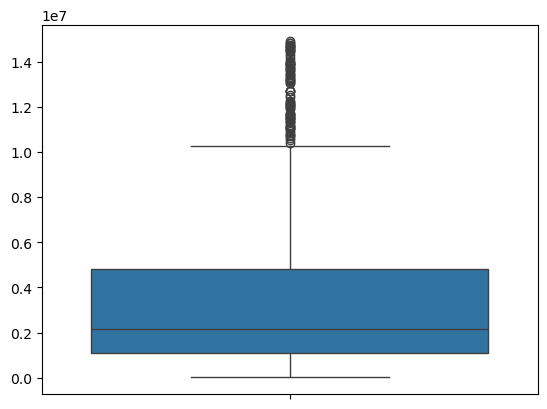

In [13]:
sns.boxplot(df['SiteEnergyUse(kBtu)'])